# Zadanie obowiązkowe [0-10] pkt

1. [0-1.5 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów SVC, zmieniając (uargumentuj wybór):
   1. funkcję jądra
   1. paramety jądra
   1. parametr `C`
1. [0-1 pkt] W przeszukaniu wyżej użyj [walidacji krzyżowej](https://scikit-learn.org/stable/modules/cross_validation.html) odpowiedniej dla zbioru niezbalansowanego
1. [0-1.5 pkt] Zbadaj zależność liczby wektorów nośnych per klasa. W tym celu wykorzystaj atrybuty `support_vectors_` i/lub `decision_function`. Czy istnieje korelacja między liczbą wektorów nośnych a dokładnością klasyfikatora?
2. [0-1 pkt] Podobnie jak w poprzedni zadaniu, zbadaj dokładność modelu w zależności od techniki skalowania oraz wyboru liczby cech
3. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyrysuj obszary decyzyjne. Weź pod uwagę, że implementacja w `scikit-learn`  działa na zasadzie OvR (*One-vs-Rest*) tzn. każdy klasyfikator uczy się oddzielnej hiperpowierzchni dla swojej klasy. Skomentuj wyniki
1. [0-1 pkt] Porównaj wyniki najlepszego modelu z `LinearSVC` z domyślnymi parametrami. Użyj MCC jako miary do porównania (uwzględnij odchylenie standardowe po podziałach w walidacji krzyżowej). Skomentuj wynik
1. [0-1 pkt] Czy w świetle uzyskanych wyników, SVC jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
1. [0-1.5 pkt] Zidentyfikuj używkę, z którą model radzi sobie najlepiej. Analiza nie musi być tak zaawansowana jak wyżej, ale powinna miarodajnie porównać wszystkie klasyfikatory między sobą. Efektywnie, chodzi o zaimplementowanie pętli po zmiennej `y` i odpowiednie dobranie parametrów w `GridSearchCV` oraz `Pipeline`
   
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

### 0. Import niezbędnych bibliotek, datasetu i jego wstępna obróbka

In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
import warnings

In [2]:
drugs = fetch_ucirepo(id=373) 
X = drugs.data.features 
y_all = drugs.data.targets
# Przewidujemy doświadczenia z grzybami halucynogennymi
y = y_all.mushrooms

idx_to_drop = y_all[y_all['semer'] != 'CL0'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

idx_to_drop = y[y == 'CL6'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_trans = label_encoder.fit_transform(y.values)

### 1 i 2. GridSearch + walidacja krzyżowa

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(max_iter=10000))
])

param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly'], # pozwoli sprawdzić różne jądra
    'svc__C': [0.1, 1, 10], # odpowiada za karę, im większa tym bardziej skomplikowany model
    'svc__gamma': ['scale', 'auto'], # scale uwzgleeni X.var, auto nie
    'svc__degree': [2, 3] # tylko dla jądra wielomianowego, stopień wielomianu
}

# stratified nadaje się do niezbalanosownego zbiory, upewnia się, że proporcje klas są zachowane w każdym foldzie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y_trans)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Najlepsze accuracy (średnia z 5-fold): {grid_search.best_score_:.2f}")

Najlepsze parametry: {'svc__C': 1, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Najlepsze accuracy (średnia z 5-fold): 0.55


### 3. Zależność liczby wektorów nośnych per klasa

Fold 1: accuracy=0.55, liczba SV=1173, per klasa=[468 165 207 210  92  31]
Fold 2: accuracy=0.53, liczba SV=1183, per klasa=[475 167 207 212  91  31]
Fold 3: accuracy=0.57, liczba SV=1172, per klasa=[468 165 207 210  91  31]
Fold 4: accuracy=0.56, liczba SV=1172, per klasa=[470 164 207 209  91  31]
Fold 5: accuracy=0.53, liczba SV=1162, per klasa=[456 166 208 209  91  32]
Korelacja pomiędzy dokładnością a liczbą wektorów nośnych: 0.05


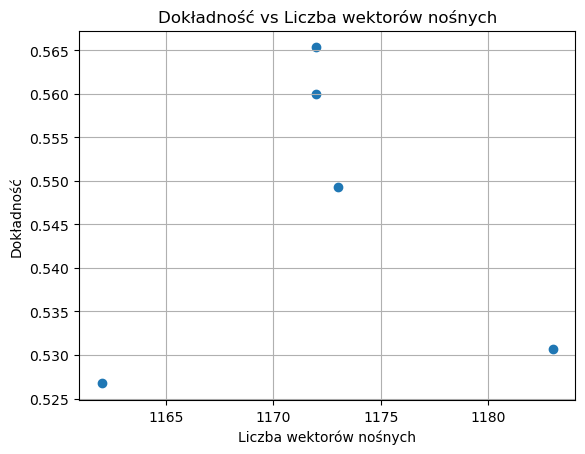

In [4]:
number_of_sv = []
accuracies = []

warnings.filterwarnings("ignore")

for fold_idx, (train_index, test_index) in enumerate(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X, y_trans)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_trans[train_index], y_trans[test_index]

    model = SVC(kernel='rbf', C=1, gamma='scale')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = (y_pred == y_test).mean()
    accuracies.append(accuracy)

    num_sv = len(model.support_vectors_)
    number_of_sv.append(num_sv)

    print(f"Fold {fold_idx+1}: accuracy={accuracy:.2f}, liczba SV={num_sv}, per klasa={model.n_support_}")

# Badanie korelacji pomiędzy dokładnością a liczbą wektorów nośnych
corr = pd.Series(accuracies).corr(pd.Series(number_of_sv))
print(f"Korelacja pomiędzy dokładnością a liczbą wektorów nośnych: {corr:.2f}")

plt.scatter(number_of_sv, accuracies)
plt.xlabel('Liczba wektorów nośnych')
plt.ylabel('Dokładność')
plt.title('Dokładność vs Liczba wektorów nośnych')
plt.grid()
plt.show()

[Komentarz] Dokładność zdaje się być najwyższa dla określonego wąskiego przedziału liczby wektorów i spadać gdy jest ich mniej lub więcej. Analiza liczby wektorów nośnych per klasa pokazuje, że niektóre z nich mają znacząco wyższą liczbę wektorów nośnych. Może to sugerować, że model ma trudności z ich rozróżnieniem.

### 4. Zależność dokładności od techniki skalowania oraz wyboru liczby cech

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

scalers = [StandardScaler, MinMaxScaler, RobustScaler]
scaler_names = ['StandardScaler', 'MinMaxScaler', 'RobustScaler']
scaler_dict = dict(zip(scaler_names, scalers))
k_values = [3, 5, 8, 10, 12]

warnings.filterwarnings('ignore')

results = []

for scaler_name, scaler in scaler_dict.items():
    for k in k_values:
        pipeline = Pipeline([
            ('scaler', scaler()),
            ('select', SelectKBest(score_func=f_classif, k=k)),
            ('svc', SVC(kernel='rbf', C=1, gamma='scale'))
        ])

        scores = cross_val_score(pipeline, X, y_trans, cv=5, scoring='accuracy')
        results.append((scaler_name, k, scores.mean(), scores.std()))
        print(f"Skalowanie: {scaler_name}, k={k}, dokładność: {scores.mean():.3f} ± {scores.std():.3f}")
    print()

Skalowanie: StandardScaler, k=3, dokładność: 0.538 ± 0.036
Skalowanie: StandardScaler, k=5, dokładność: 0.541 ± 0.036
Skalowanie: StandardScaler, k=8, dokładność: 0.544 ± 0.037
Skalowanie: StandardScaler, k=10, dokładność: 0.536 ± 0.034
Skalowanie: StandardScaler, k=12, dokładność: 0.544 ± 0.028

Skalowanie: MinMaxScaler, k=3, dokładność: 0.540 ± 0.035
Skalowanie: MinMaxScaler, k=5, dokładność: 0.539 ± 0.029
Skalowanie: MinMaxScaler, k=8, dokładność: 0.543 ± 0.037
Skalowanie: MinMaxScaler, k=10, dokładność: 0.543 ± 0.037
Skalowanie: MinMaxScaler, k=12, dokładność: 0.538 ± 0.030

Skalowanie: RobustScaler, k=3, dokładność: 0.541 ± 0.040
Skalowanie: RobustScaler, k=5, dokładność: 0.538 ± 0.033
Skalowanie: RobustScaler, k=8, dokładność: 0.544 ± 0.036
Skalowanie: RobustScaler, k=10, dokładność: 0.538 ± 0.035
Skalowanie: RobustScaler, k=12, dokładność: 0.538 ± 0.030



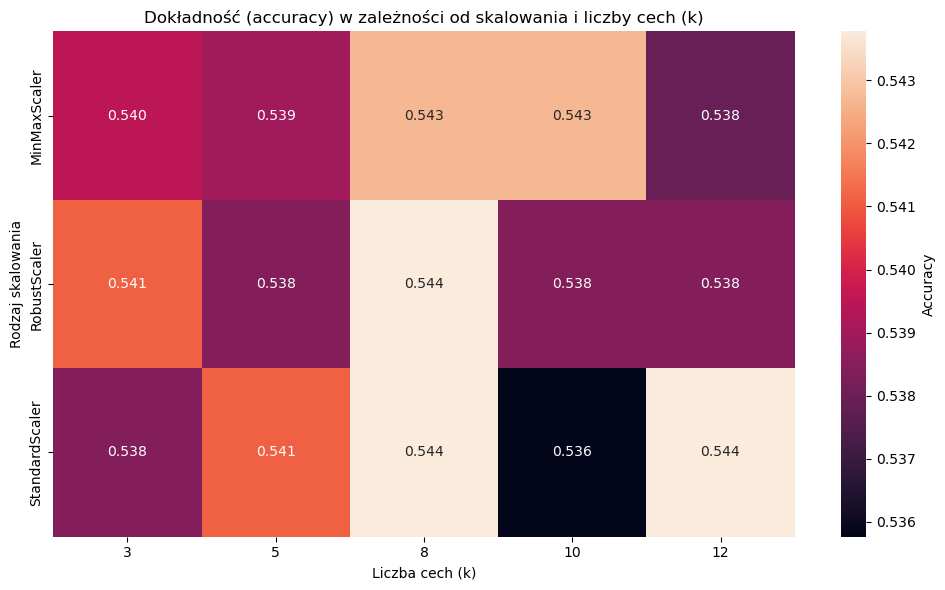

In [6]:
import seaborn as sns
results_df = pd.DataFrame(results, columns=['Scaler', 'k', 'Accuracy Mean', 'Accuracy Std'])
pivot_table = results_df.pivot(index='Scaler', columns='k', values='Accuracy Mean')

# Rysowanie heatmapy
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cbar_kws={'label': 'Accuracy'})
plt.title("Dokładność (accuracy) w zależności od skalowania i liczby cech (k)")
plt.xlabel("Liczba cech (k)")
plt.ylabel("Rodzaj skalowania")
plt.tight_layout()
plt.show()

[Komentarz] Wybór rodzaju skalowania i liczby cech nie miał dużego znaczenia.

### 5. Obszary decyzyjne dla najelepszej pary

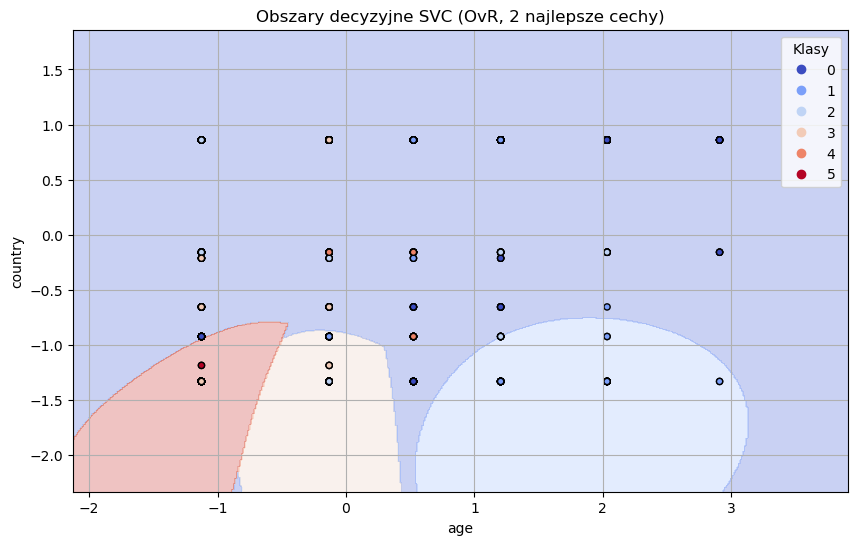

In [7]:
# Wybór cech
selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X, y_trans)
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_scaled, y_trans)

# Przygotowanie wykresu
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_trans, s=20, edgecolors='k', cmap=plt.cm.coolwarm)
plt.xlabel(selected_feature_names[0])
plt.ylabel(selected_feature_names[1])
plt.title("Obszary decyzyjne SVC (OvR, 2 najlepsze cechy)")
plt.legend(*scatter.legend_elements(), title="Klasy")
plt.grid(True)
plt.show()

[Komentarz] Wizualizacja pokazuje, że jedna z wybranych cech ma charakter dyskretny, co utrudnia jej odpowiednie przedstawienie na wykresie. Choć obszary decyzyjne wydają się sensowne i nie są losowe, to jednak ich interpretacja jest trudna. Najistotniejszymi w konteście podziału okazały się wiek i kraj.

### 6. Porównanie najlepszego modelu z liniowym

In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.svm import LinearSVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)

# Pipeline dla najlepszego modelu
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1, gamma='scale'))
])
svc_scores = cross_val_score(svc_pipeline, X, y_trans, cv=cv, scoring=mcc_scorer)

# Pipeline dla LinearSVC z domyślnymi parametrami
linear_svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lsvc', LinearSVC(max_iter=10000))
])
linear_scores = cross_val_score(linear_svc_pipeline, X, y_trans, cv=cv, scoring=mcc_scorer)

# Porównanie
print("SVC (linear):")
print(f"  MCC: {svc_scores.mean():.3f} ± {svc_scores.std():.3f}")

print("LinearSVC:")
print(f"  MCC: {linear_scores.mean():.3f} ± {linear_scores.std():.3f}")

SVC (linear):
  MCC: 0.237 ± 0.025
LinearSVC:
  MCC: 0.237 ± 0.023


[Komentarz] Wyniki okazały się w zasadzie identyczne. Dane wydają się być liniowo separowlane.

### 7. Czy w świetle uzyskanych wyników, SVC jest odpowiednim klasyfikatorem do tego problemu?

SVC nie przewyższyło prostszego modelu, więc lepiej sięgnąć po linearSVC.

### 8. Identyfikacja używki, z którą model radzi sobie najlepiej

In [ ]:
y_all_filtered = y_all.loc[X.index]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)

results = []

for col in y_all_filtered.columns:
    y = y_all_filtered[col].dropna()
    X_matched = X.loc[y.index]

    if len(y.unique()) <= 1:
        continue

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=1, gamma='scale'))
    ])

    param_grid = {
        'svc__C': [0.1, 1, 10] # szukam balansu miedzy złożonością a dokładnością
    }

    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring=mcc_scorer, n_jobs=-1)

    grid.fit(X_matched, y_encoded)
    results.append({
        'Substancja': col,
        'Najlepszy MCC': grid.best_score_
    })

results_df = pd.DataFrame(results).sort_values(by='Najlepszy MCC', ascending=False)
print(results_df.head(10))  # Top 10 substancji

   Substancja  Najlepszy MCC
12     legalh       0.317911
13        lsd       0.282877
5    cannabis       0.279571
15  mushrooms       0.236674
16   nicotine       0.190449
9     ecstasy       0.186943
7        coke       0.183560
2        amyl       0.170310
1      amphet       0.150589
3      benzos       0.135438


[Komentarz] Najlepiej klasyfikowaną etykietą okazała się legalh (legal highs). Wysokie wyniki osiągają także lsd oraz cannabis, co sugeruje, że cechy opisujące użytkowników tych substancji pozwalają na względnie skuteczne ich rozróżnianie. Z kolei substancje takie jak benzos czy amphet sugerują nakładanie się klas.